In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, recall_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
train = pd.read_csv('../../../../Data/fraudTrain_cleaned.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 26 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   trans_date_trans_time   1296675 non-null  object 
 1   cc_num                  1296675 non-null  int64  
 2   merchant                1296675 non-null  object 
 3   category                1296675 non-null  object 
 4   amt                     1296675 non-null  float64
 5   gender                  1296675 non-null  object 
 6   city                    1296675 non-null  object 
 7   state                   1296675 non-null  object 
 8   zip                     1296675 non-null  int64  
 9   job                     1296675 non-null  object 
 10  is_fraud                1296675 non-null  int64  
 11  txn_distance_km         1296675 non-null  float64
 12  year                    1296675 non-null  int64  
 13  month                   1296675 non-null  int64  
 14  is

## 🧭 Step-by-Step EDA Section

### 1. Distribution of Numerical Distribution

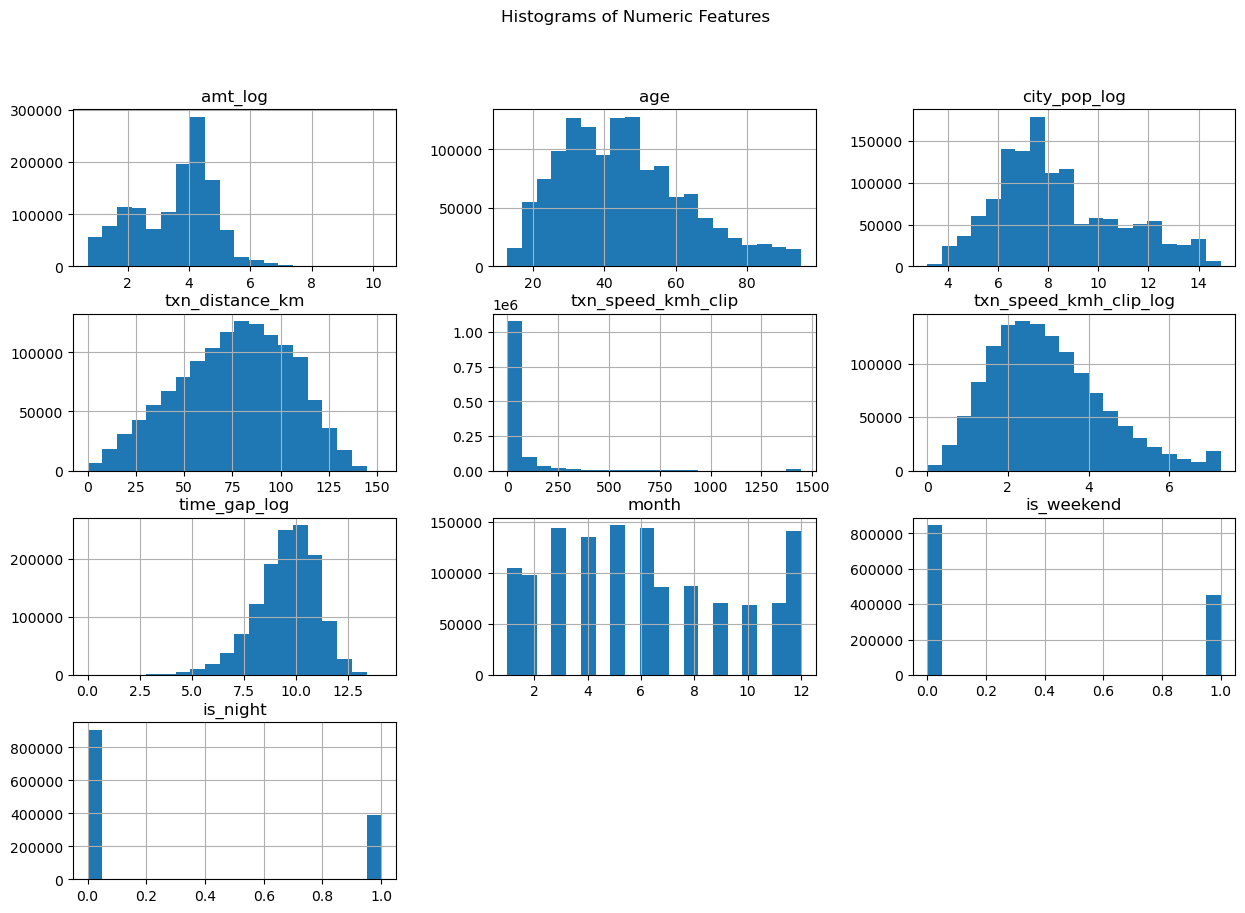

In [3]:
numeric_cols = [
    # Core continuous
    'amt_log', 'age', 'city_pop_log', 'txn_distance_km', 'txn_speed_kmh_clip', 'txn_speed_kmh_clip_log', 'time_gap_log',
    # Semi-numeric (useful for pattern)
    'month', 'is_weekend', 'is_night'
]

train[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Numeric Features")

plt.show()

### 2. Distribution of Categorical Vars

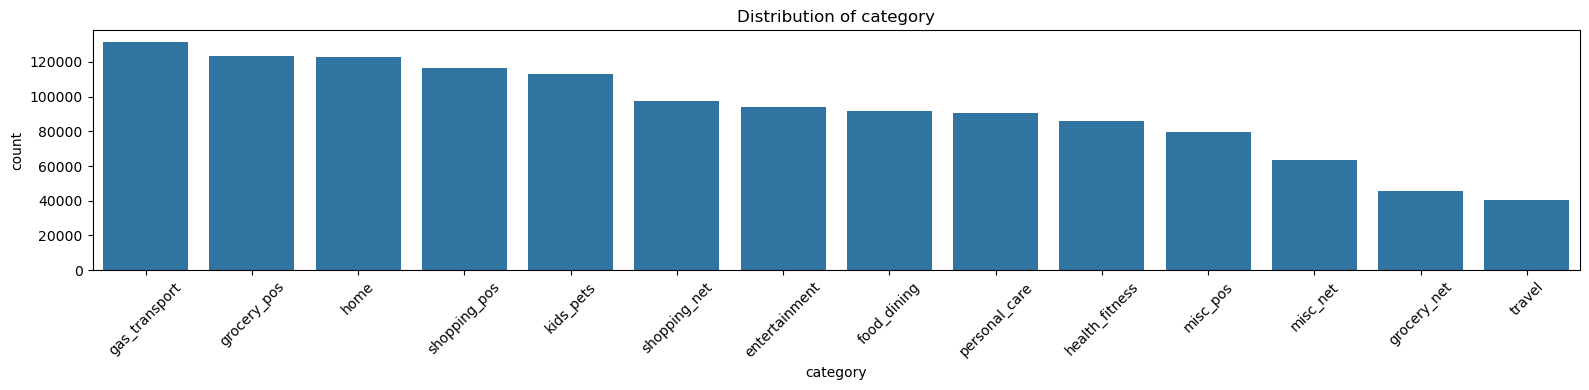

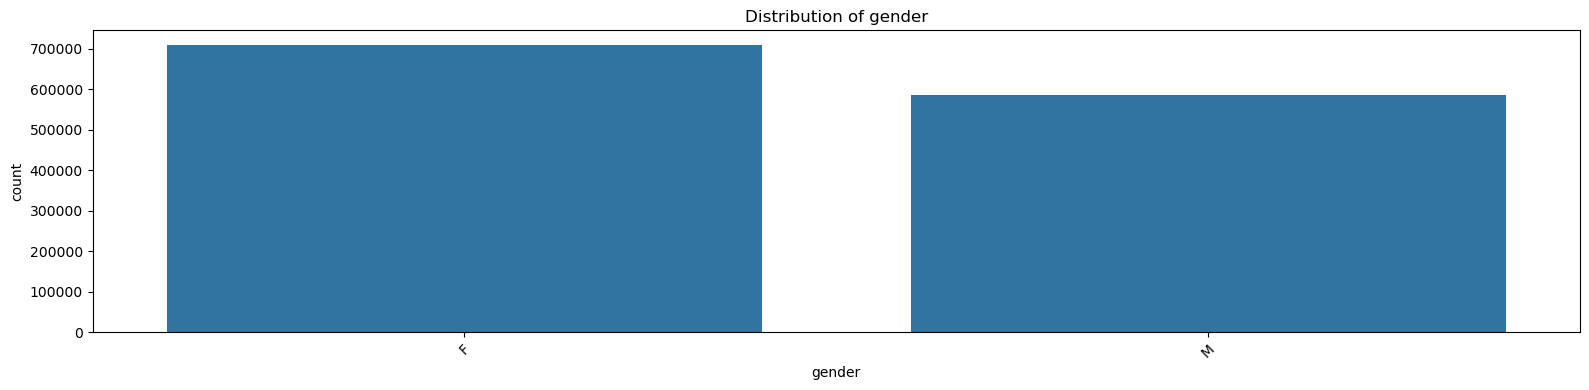

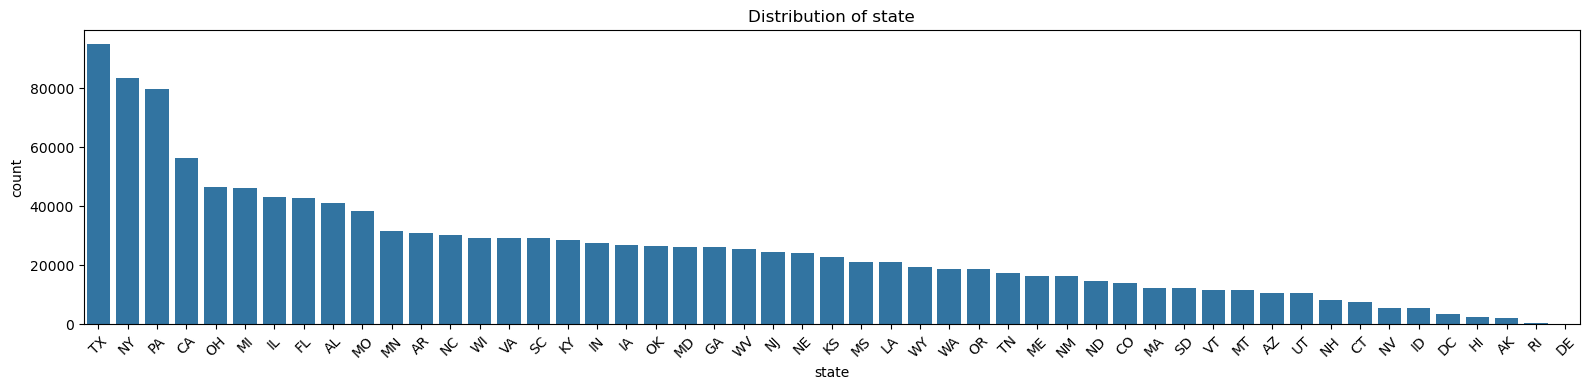

In [4]:
categorical_cols = [
    'category', 'gender', 'state'
]

for col in categorical_cols:
    plt.figure(figsize=(16, 4))
    sns.countplot(x=col, data=train, order=train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

### 3.Global Average Fraud Rate

In [5]:
round(train['is_fraud'].mean(), 6)

0.005789

### 4. Fraud Rate by Category

In [6]:
train.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

category
shopping_net      0.017561
misc_net          0.014458
grocery_pos       0.014098
shopping_pos      0.007225
gas_transport     0.004694
misc_pos          0.003139
grocery_net       0.002948
travel            0.002864
entertainment     0.002478
personal_care     0.002424
kids_pets         0.002114
food_dining       0.001651
home              0.001608
health_fitness    0.001549
Name: is_fraud, dtype: float64

Online transactions are significantly more vulnerable to fraud. Health_fitness, home, and food_dining are relativily low due to the fact that daily spending tends to be more stable, making them less susceptible to fraud.

### 5. Fraud Rate by Merchant

In [7]:
train.groupby('merchant')['is_fraud'].mean().sort_values(ascending=False).head(50)

merchant
fraud_Kozey-Boehm                             0.025723
fraud_Herman, Treutel and Dickens             0.025385
fraud_Kerluke-Abshire                         0.022307
fraud_Brown PLC                               0.022109
fraud_Goyette Inc                             0.021616
fraud_Terry-Huel                              0.021543
fraud_Jast Ltd                                0.021505
fraud_Schmeler, Bashirian and Price           0.020833
fraud_Boyer-Reichert                          0.019916
fraud_Langworth, Boehm and Gulgowski          0.019807
fraud_Moore, Dibbert and Koepp                0.019747
fraud_Baumbach, Feeney and Morar              0.019699
fraud_Rau and Sons                            0.019679
fraud_Gleason-Macejkovic                      0.019675
fraud_Kuhic LLC                               0.019647
fraud_Kuhic, Bins and Pfeffer                 0.019471
fraud_Price Inc                               0.019163
fraud_Tillman, Fritsch and Schmitt            0.019128
f

### 6. Speed vs Fraud

<Axes: xlabel='amt_log'>

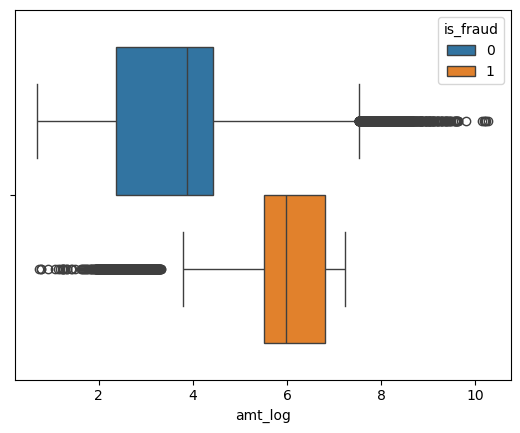

In [8]:
sns.boxplot(data=train, x='amt_log', hue='is_fraud')

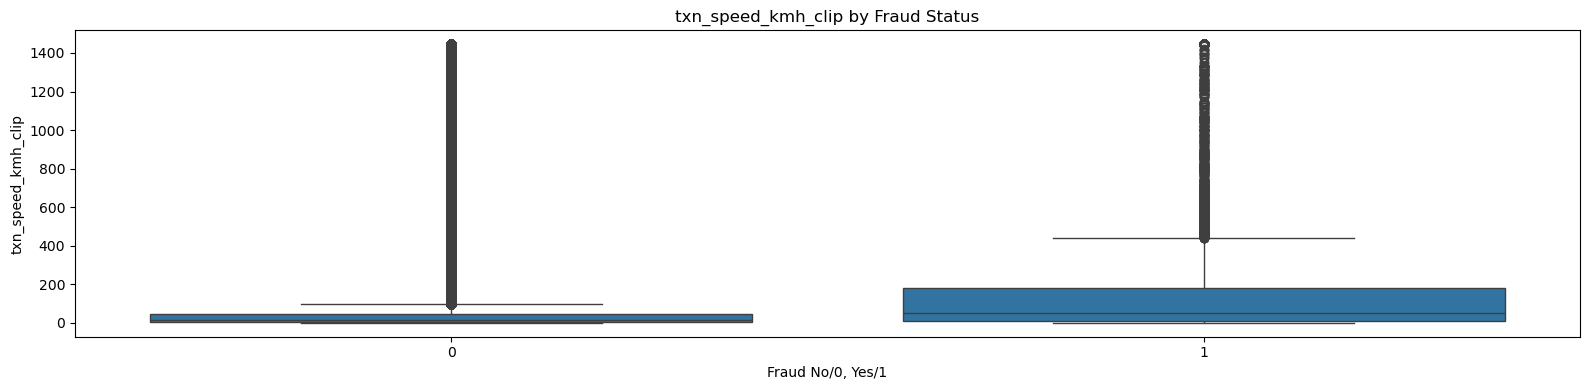

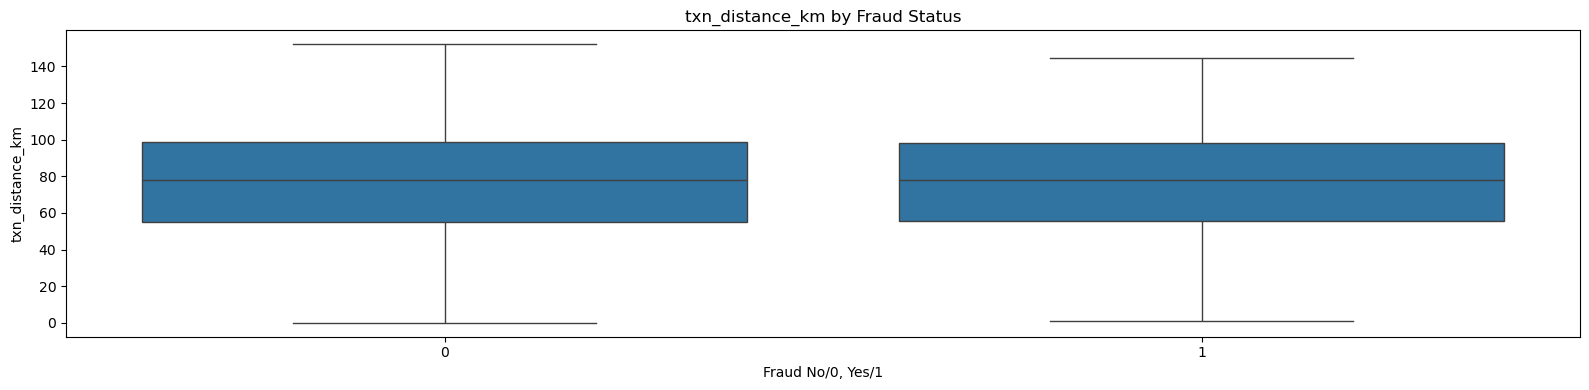

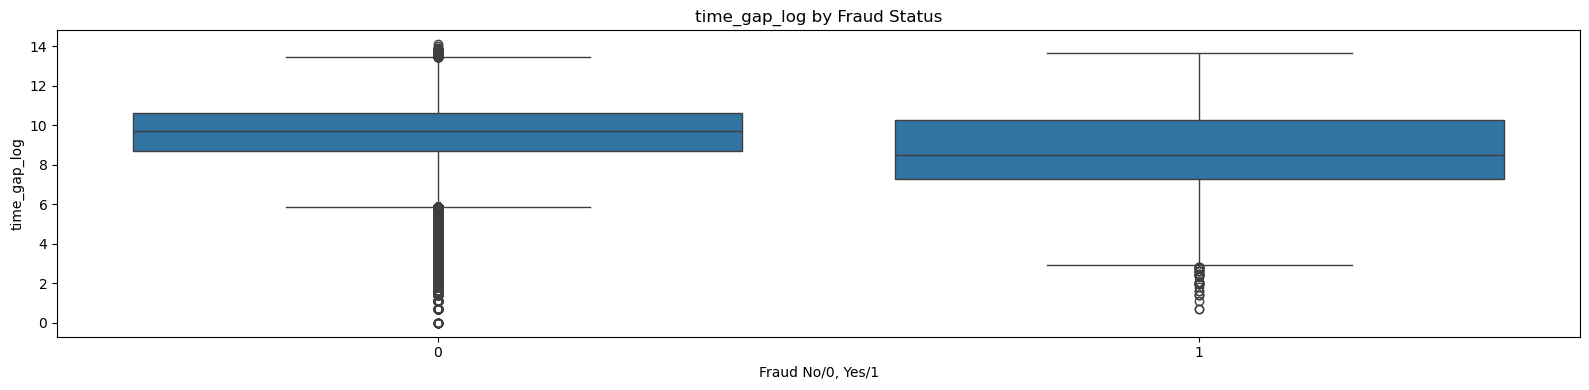

In [9]:
boxplot_cols = [
    'txn_speed_kmh_clip', 'txn_distance_km', 'time_gap_log'
]

for col in boxplot_cols:
    plt.figure(figsize=(16, 4))
    sns.boxplot(data=train, x='is_fraud', y=col)
    plt.title(f"{col} by Fraud Status")
    plt.xlabel("Fraud No/0, Yes/1")
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


<Axes: xlabel='month'>

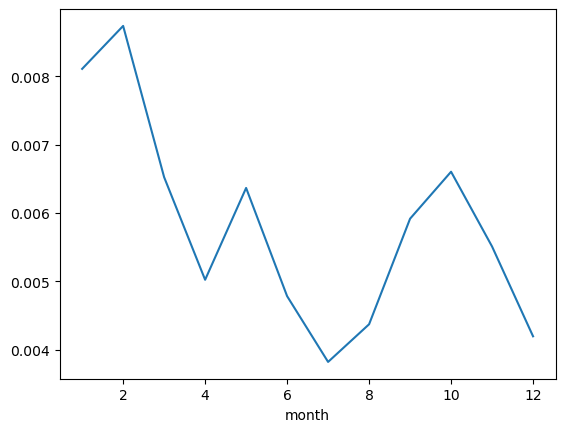

In [10]:
train.groupby('month')['is_fraud'].mean().plot()

Text(0.5, 1.0, 'Fraud vs Non-Fraud Amount Distribution (Log Scale)')

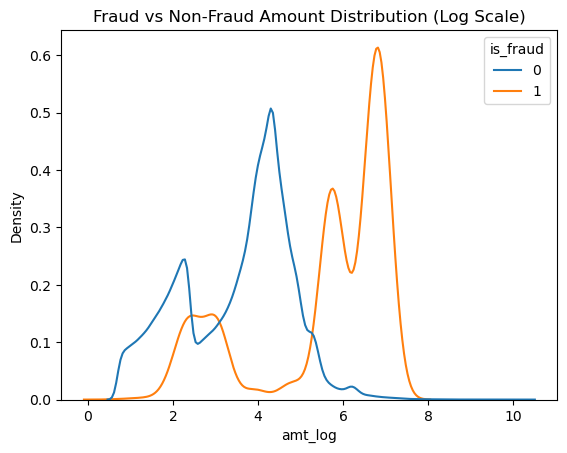

In [11]:
sns.kdeplot(
    data=train,
    x="amt_log",
    hue="is_fraud",
    common_norm=False
)

plt.title("Fraud vs Non-Fraud Amount Distribution (Log Scale)")

### 7. txn_speed vs time_gap

<Axes: >

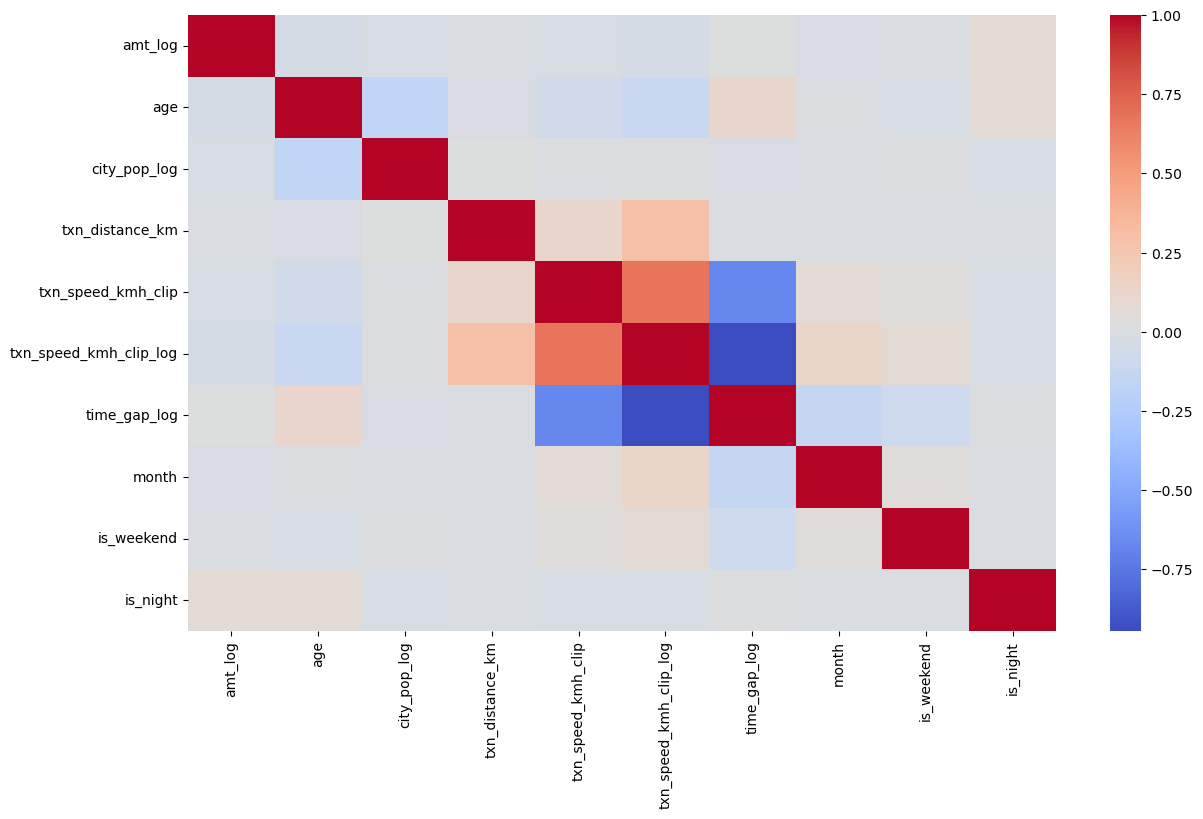

In [12]:
plt.figure(figsize=(14, 8))
sns.heatmap(train[numeric_cols].corr(), cmap='coolwarm')

High transaction speed occurs when geographically distant transactions happen within a short time interval, indicating anomalous behavior. Transaction speed and time gap exhibit strong negative correlation. 

### Risk Stratification

In [13]:
train.sort_values('amt_log', ascending=False).head(5000)['is_fraud'].mean()

0.3174

In [14]:
k_list = [1000, 2000, 5000, 10000, 10500, 11000, 12000, 15000]

for k in k_list:
    rate = train.sort_values('amt_log', ascending=False).head(k)['is_fraud'].mean()
    print(k, rate)

1000 0.0
2000 0.0145
5000 0.3174
10000 0.3505
10500 0.33685714285714285
11000 0.3230909090909091
12000 0.29825
15000 0.24273333333333333


Fraud is not uniformly distributed across transaction amounts. Instead, it is concentrated within a specific high-value range, rather than the absolute highest transactions.

Fraud pattern:
- abs high value transaction -> strict risk control -> less fraud
- mid-high and high value transaction -> sweet spot where most fraud occurs

In [15]:
def merchant_feature_engineering(df, merchant_col='merchant'):
    df = df.copy()

    # Step1: clean merchant
    df['merchant_clean'] = (
        df[merchant_col]
        .str.replace('fraud_', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.lower()
        .str.strip()
    )

    # Step2: extract merchant type
    def extract_type(x):
        if x.endswith('llc'):
            return 'llc'
        elif x.endswith('inc'):
            return 'inc'
        elif x.endswith('ltd'):
            return 'ltd'
        elif 'group' in x:
            return 'group'
        elif 'and sons' in x:
            return 'family_business'
        else:
            return 'other'

    df['merchant_type'] = df['merchant_clean'].apply(extract_type)

    # Step3: Drop the original column
    df = df.drop(columns=[merchant_col])

    return df

In [16]:
train = merchant_feature_engineering(train)
train.head()

,trans_date_trans_time,cc_num,category,amt,gender,city,state,zip,job,is_fraud,...,dow_sin,dow_cos,txn_speed_kmh_clip,time_gap_log,txn_speed_kmh_clip_log,amt_log,city_pop_log,age,merchant_clean,merchant_type
0,2019-01-01 12:47:15,60416207185,misc_net,7.27,F,Fort Washakie,WY,82514,Information systems manager,0,...,0.781831,0.623490,NaN,NaN,NaN,2.112635,7.406103,32,jones sawayn and romaguera,other
1,2019-01-02 08:44:57,60416207185,gas_transport,52.94,F,Fort Washakie,WY,82514,Information systems manager,0,...,0.974928,-0.222521,5.526038,11.182517,1.875800,3.987872,7.406103,32,berge llc,llc
2,2019-01-02 08:47:36,60416207185,gas_transport,82.08,F,Fort Washakie,WY,82514,Information systems manager,0,...,0.974928,-0.222521,493.296481,5.075174,6.203136,4.419804,7.406103,32,luettgen plc,other
3,2019-01-02 12:38:14,60416207185,kids_pets,34.79,F,Fort Washakie,WY,82514,Information systems manager,0,...,0.974928,-0.222521,22.686456,9.535246,3.164903,3.577669,7.406103,32,daugherty llc,llc
4,2019-01-02 13:10:46,60416207185,home,27.18,F,Fort Washakie,WY,82514,Information systems manager,0,...,0.974928,-0.222521,136.868174,7.577122,4.926298,3.338613,7.406103,32,beier and sons,family_business


In [17]:
import os

data_path = os.path.join("..", "..", "..", "..", "Data", "fraudTrain_model.csv")

train.to_csv(data_path, index=False)

The exploratory analysis identified strong fraud signals in transaction category, merchant behavior, transaction speed, time gap, and high-value transaction ranges. Based on these findings, the next stage will focus on building time-aware machine learning models with leakage-safe target encoding and time-series cross-validation.